# A Brief Analysis on the World Terrorism – Its Patterns and Trends
## Final Project
#### The Global Terrorism Database (GTD) is an open-source database including information on terrorist attacks around the world from 1970 through 2017. The GTD includes systematic data on domestic as well as international terrorist incidents that have occurred during this time and now includes more than 180,000 attacks. The database is maintained by researchers at the National Consortium for the Study of Terrorism and Responses to Terrorism (START), headquartered at the University of Maryland.The analysis commenced with data preprocessing, including handling missing values, removing duplicates, Exploratory data analysis (EDA) techniques were employed to visualize trends and patterns. 

## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     #for visualization
%matplotlib inline
import seaborn as sns               #for visualization
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## Exploring Dataset

In [24]:
df = pd.read_excel(r"terror.xlsx")
df.head()

,eventid,year,month,date,extended,country,region,provstate,city,latitude,...,targtype,targsubtype,target_nationality,gang,motive,weaptype,weapsubtype,weapdetail,kills,ransom
0,197000000001,1970,7,2,0,Dominican Republic,Central America & Caribbean,National,Santo Domingo,18.456792,...,Private Citizens & Property,Named Civilian,Dominican Republic,MANO-D,NaN,Unknown,NaN,NaN,1.0,0.0
1,197000000002,1970,0,0,0,Mexico,North America,Federal,Mexico city,19.371887,...,Government (Diplomatic),"Diplomatic Personnel (outside of embassy, cons...",Belgium,23rd of September Communist League,NaN,Unknown,NaN,NaN,0.0,1.0
2,197001000001,1970,1,0,0,Philippines,Southeast Asia,Tarlac,Unknown,15.478598,...,Journalists & Media,Radio Journalist/Staff/Facility,United States,Unknown,NaN,Unknown,NaN,NaN,1.0,0.0
3,197001000002,1970,1,0,0,Greece,Western Europe,Attica,Athens,37.997490,...,Government (Diplomatic),Embassy/Consulate,United States,Unknown,NaN,Explosives,Unknown Explosive Type,Explosive,NaN,0.0
4,197001000003,1970,1,0,0,Japan,East Asia,Fukouka,Fukouka,33.580412,...,Government (Diplomatic),Embassy/Consulate,United States,Unknown,NaN,Incendiary,NaN,Incendiary,NaN,0.0


In [25]:
df.shape

(209706, 27)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209706 entries, 0 to 209705
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   eventid             209706 non-null  int64  
 1   year                209706 non-null  int64  
 2   month               209706 non-null  int64  
 3   date                209706 non-null  int64  
 4   extended            209706 non-null  int64  
 5   country             209706 non-null  object 
 6   region              209706 non-null  object 
 7   provstate           209706 non-null  object 
 8   city                209279 non-null  object 
 9   latitude            205015 non-null  float64
 10  longitude           205014 non-null  float64
 11  specificity         209705 non-null  float64
 12  vicinity            209706 non-null  int64  
 13  location            67475 non-null   object 
 14  success             209706 non-null  int64  
 15  suicide             209706 non-nul

In [27]:
df.describe()

,eventid,year,month,date,extended,latitude,longitude,specificity,vicinity,success,suicide,kills,ransom
count,2.097060e+05,209706.000000,209706.000000,209706.000000,209706.000000,205015.000000,205014.000000,209705.000000,209706.000000,209706.000000,209706.000000,197179.000000,80466.000000
mean,2.004867e+11,2004.800993,6.455285,15.527930,0.051525,23.358696,30.416738,1.468387,0.068854,0.883628,0.035469,2.431030,-0.157520
std,1.351933e+09,13.519321,3.387098,8.801104,0.221066,18.137061,56.113029,0.984958,0.281308,0.320672,0.184962,11.340882,1.255812
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,-53.154613,-176.176447,1.000000,-9.000000,0.000000,0.000000,0.000000,-9.000000
25%,1.992080e+11,1992.000000,4.000000,8.000000,0.000000,11.510046,8.748117,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,2.012010e+11,2012.000000,6.000000,15.000000,0.000000,31.300213,43.746215,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,2.015123e+11,2015.000000,9.000000,23.000000,0.000000,34.557022,68.835918,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000
max,2.020123e+11,2020.000000,12.000000,31.000000,1.000000,74.633553,179.366667,5.000000,1.000000,1.000000,1.000000,1700.000000,1.000000


In [28]:
df.columns

Index(['eventid', 'year', 'month', 'date', 'extended', 'country', 'region',
       'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity',
       'location', 'success', 'suicide', 'attacktype', 'targtype',
       'targsubtype', 'target_nationality', 'gang', 'motive', 'weaptype',
       'weapsubtype', 'weapdetail', 'kills', 'ransom'],
      dtype='object')

In [29]:
df.dtypes

eventid                 int64
year                    int64
month                   int64
date                    int64
extended                int64
country                object
region                 object
provstate              object
city                   object
latitude              float64
longitude             float64
specificity           float64
vicinity                int64
location               object
success                 int64
suicide                 int64
attacktype             object
targtype               object
targsubtype            object
target_nationality     object
gang                   object
motive                 object
weaptype               object
weapsubtype            object
weapdetail             object
kills                 float64
ransom                float64
dtype: object

# Data Preprocessing


## Handling NULL Values


In [30]:
df.isnull().sum()

eventid                    0
year                       0
month                      0
date                       0
extended                   0
country                    0
region                     0
provstate                  0
city                     427
latitude                4691
longitude               4692
specificity                1
vicinity                   0
location              142231
success                    0
suicide                    0
attacktype                 0
targtype                   0
targsubtype            11839
target_nationality      2014
gang                       0
motive                154648
weaptype                   0
weapsubtype            25941
weapdetail             86569
kills                  12527
ransom                129240
dtype: int64

Text(0.5, 23.38159722222222, '')

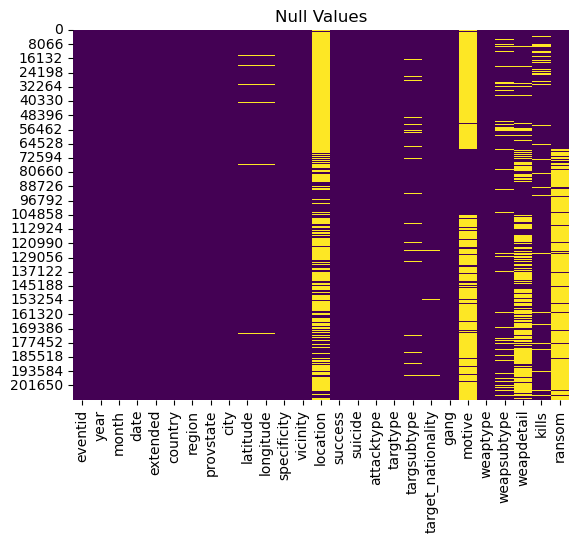

In [31]:
df=df.reset_index(drop=True)
g1 = sns.heatmap(df.isna(), cbar=False, cmap='viridis')
g1.set_title('Null Values')
g1.set_ylabel('')
g1.set_xlabel('')

### Provincial State and City
#### Since the state and city information cannot be randomly assigned, we will assume that these details are unknown. To address this, we will fill all missing values in the state and city columns with "Unknown". This approach ensures consistency in the dataset while acknowledging the gaps in our location data.

In [32]:
df["provstate"].fillna("Unknown", inplace=True)
df["city"].fillna("Unknown", inplace=True)

In [33]:
df["provstate"]

0             National
1              Federal
2               Tarlac
3               Attica
4              Fukouka
              ...     
209701     Al Hudaydah
209702     Al Hudaydah
209703    Lower Saxony
209704           Kabul
209705           Sahel
Name: provstate, Length: 209706, dtype: object

In [34]:
df["city"]

0         Santo Domingo
1           Mexico city
2               Unknown
3                Athens
4               Fukouka
              ...      
209701            Sabaa
209702     Beit Maghari
209703          Leipzig
209704            Kabul
209705            Kelbo
Name: city, Length: 209706, dtype: object

In [35]:
df.isnull().sum()

eventid                    0
year                       0
month                      0
date                       0
extended                   0
country                    0
region                     0
provstate                  0
city                       0
latitude                4691
longitude               4692
specificity                1
vicinity                   0
location              142231
success                    0
suicide                    0
attacktype                 0
targtype                   0
targsubtype            11839
target_nationality      2014
gang                       0
motive                154648
weaptype                   0
weapsubtype            25941
weapdetail             86569
kills                  12527
ransom                129240
dtype: int64

### Specificity
#### Only 1 NULL value present so we can drop that row easily

In [36]:
df=df[df['specificity'].notna()]

#### Since the following information cannot be randomly assigned, we will assume that these details are unknown. To address this, we will fill all missing values in the column with "Unknown". This approach ensures consistency in the dataset while acknowledging the gaps in our location data.
### Location


In [37]:
df["location"].fillna("Unknown", inplace=True)

### Target type and Nationality

In [38]:
df["targsubtype"].fillna("Unknown", inplace=True)
df["target_nationality"].fillna("Unknown", inplace=True)

### Motive

In [39]:
df["motive"].fillna("Unknown", inplace=True)

### Weapon Subtype and Details

In [40]:
df["weapsubtype"].fillna("Unknown", inplace=True)
df["weapdetail"].fillna("Unknown", inplace=True)

In [41]:
df.isnull().sum()

eventid                    0
year                       0
month                      0
date                       0
extended                   0
country                    0
region                     0
provstate                  0
city                       0
latitude                4690
longitude               4691
specificity                0
vicinity                   0
location                   0
success                    0
suicide                    0
attacktype                 0
targtype                   0
targsubtype                0
target_nationality         0
gang                       0
motive                     0
weaptype                   0
weapsubtype                0
weapdetail                 0
kills                  12527
ransom                129239
dtype: int64

### Ransom

In [42]:
df[df['ransom'].isnull()]['attacktype'].value_counts()

attacktype
Bombing/Explosion                      69497
Armed Assault                          33356
Assassination                           8967
Unknown                                 8289
Facility/Infrastructure Attack          7678
Unarmed Assault                          821
Hostage Taking (Kidnapping)              413
Hijacking                                191
Hostage Taking (Barricade Incident)       27
Name: count, dtype: int64

#### In cases where the type of attack is classified as kidnapping, it is often associated with ransom demands. Therefore, we will assign a value of 1 to the 'Ransom' column for all records where the attack type is kidnapping. For all other types of attacks, the 'Ransom' column will be filled with a value of 0. This methodological approach ensures that our dataset accurately reflects the typical motives behind different types of attacks.

In [43]:
df['ransom'] = df['attacktype'].apply(lambda x: 1 if x == 'Hostage Taking (Kidnapping)' else 0)

In [44]:
df['ransom'] = df['ransom'].replace(-9, 1)

In [45]:
df['ransom'].isnull().sum()

0

### Kills

In [47]:
kill_counts = df['kills'].value_counts()
kill_counts

kills
0.0      99350
1.0      42456
2.0      16627
3.0       9195
4.0       5959
         ...  
184.0        1
210.0        1
212.0        1
287.0        1
222.0        1
Name: count, Length: 210, dtype: int64

In [52]:
df['kills'] = df['kills'].apply(lambda x: np.random.randint(0, 15) if pd.isnull(x) else x)

In [53]:
df.isnull().sum()

eventid                  0
year                     0
month                    0
date                     0
extended                 0
country                  0
region                   0
provstate                0
city                     0
latitude              4690
longitude             4691
specificity              0
vicinity                 0
location                 0
success                  0
suicide                  0
attacktype               0
targtype                 0
targsubtype              0
target_nationality       0
gang                     0
motive                   0
weaptype                 0
weapsubtype              0
weapdetail               0
kills                    0
ransom                   0
dtype: int64

## Analysis and Interpretations

### 1. Trend Analysis: How has the frequency of terrorist attacks changed over the years globally? Further break down this trend by regions to identify specific areas with increasing or decreasing activity.
##### Global Trend Analysis: The first plot provides a visual representation of the global frequency of terrorist attacks over the years, illustrating whether the trend is increasing, decreasing, or stable.
##### Regional Trend Analysis: The second plot breaks down these trends by region, helping to identify specific areas with increasing or decreasing activity. This can show how different regions are affected over time and can be useful for geopolitical analysis and security planning.

#### First we analyze the frequecy of attacks for each year

In [70]:
attacks_by_year = df['year'].value_counts().sort_index()

In [71]:
attacks_by_year

year
1970      651
1971      471
1972      567
1973      473
1974      581
1975      740
1976      923
1977     1319
1978     1526
1979     2662
1980     2661
1981     2586
1982     2543
1983     2870
1984     3495
1985     2914
1986     2860
1987     3183
1988     3720
1989     4324
1990     3886
1991     4685
1992     5071
1994     3456
1995     3081
1996     3058
1997     3198
1998      934
1999     1396
2000     1823
2001     1912
2002     1330
2003     1280
2004     1164
2005     2017
2006     2757
2007     3250
2008     4800
2009     4723
2010     4827
2011     5075
2012     8525
2013    12047
2014    16960
2015    15138
2016    14051
2017    11364
2018     9853
2019     8537
2020     8438
Name: count, dtype: int64

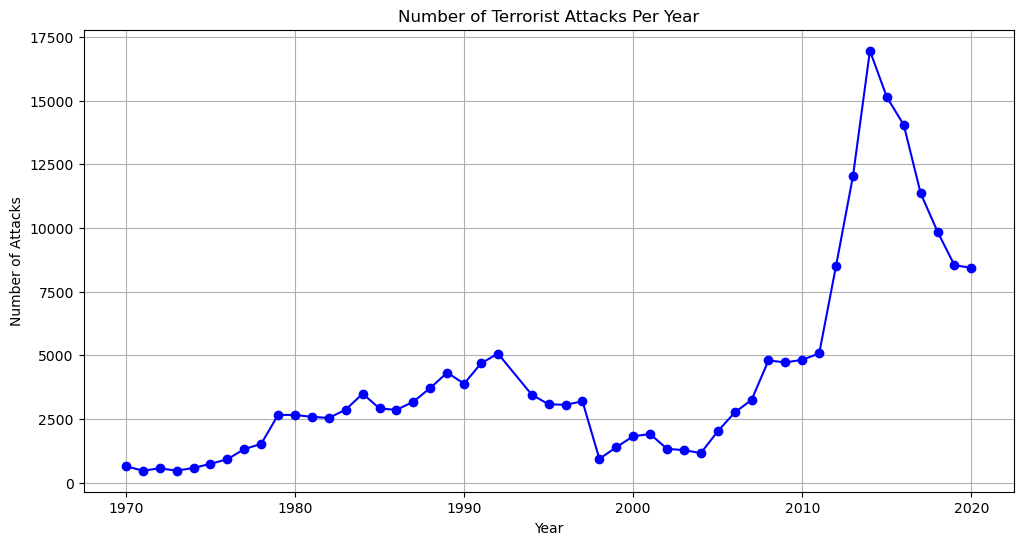

In [72]:
plt.figure(figsize=(12, 6))
attacks_by_year.plot(kind='line', marker='o', color='b')
plt.title('Number of Terrorist Attacks Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.show()

In [150]:
attacks_by_region = df.groupby(['year', 'region']).size().unstack(fill_value=0)
attacks_by_region

region,Australasia & Oceania,Central America & Caribbean,Central Asia,East Asia,Eastern Europe,Middle East & North Africa,North America,South America,South Asia,Southeast Asia,Sub-Saharan Africa,Western Europe
year,,,,,,,,,,,,
1970,1,6,0,2,12,28,472,63,1,9,0,49
1971,1,4,0,1,5,52,247,23,0,5,1,124
1972,3,3,0,0,0,52,73,25,1,15,4,374
1973,1,6,0,2,1,19,64,78,1,1,4,288
1974,1,11,0,4,2,42,111,81,2,3,5,315
1975,0,9,0,10,0,44,159,53,4,6,10,432
1976,0,42,0,2,0,51,124,90,4,7,8,572
1977,0,23,0,4,2,209,149,104,2,8,27,764
1978,2,187,0,35,2,126,115,209,2,41,31,705


<Figure size 1200x600 with 0 Axes>

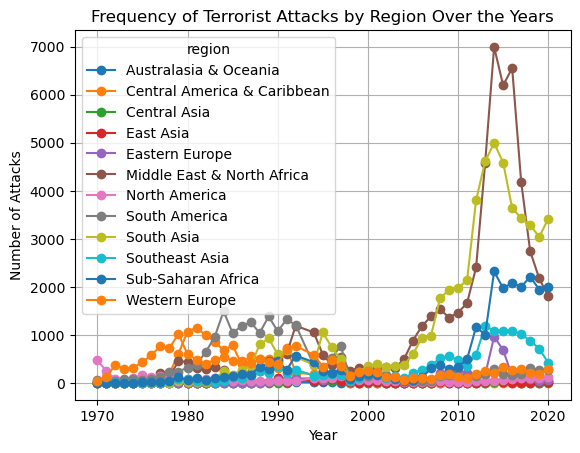

In [85]:
plt.figure(figsize=(12, 6))
attacks_by_region.plot(kind='line', marker='o')
plt.title('Frequency of Terrorist Attacks by Region Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.show()

#### The data indicates a notable trend where the highest number of attacks occurred in 2014, contrasting with the lowest recorded attacks in 1971. Additionally, the Middle East and North Africa regions  experienced the highest peak of total attacks over the years, highlighting the prevalence of conflict and instability in these areas.

### 2. Effectiveness of Attacks: Analyze the success rate of terrorist attacks. What factors contribute to the success or failure of these attacks? Consider aspects such as the type of attack, weaponry used, and target type.

In [91]:
overall_success_rate = df['success'].mean()
overall_success_rate

0.8836269998330989

In [92]:
success_by_attack_type = df.groupby('attacktype')['success'].mean()
success_by_attack_type

attacktype
Armed Assault                          0.934757
Assassination                          0.744324
Bombing/Explosion                      0.874589
Facility/Infrastructure Attack         0.947343
Hijacking                              0.890646
Hostage Taking (Barricade Incident)    0.990484
Hostage Taking (Kidnapping)            0.978426
Unarmed Assault                        0.871440
Unknown                                0.803509
Name: success, dtype: float64

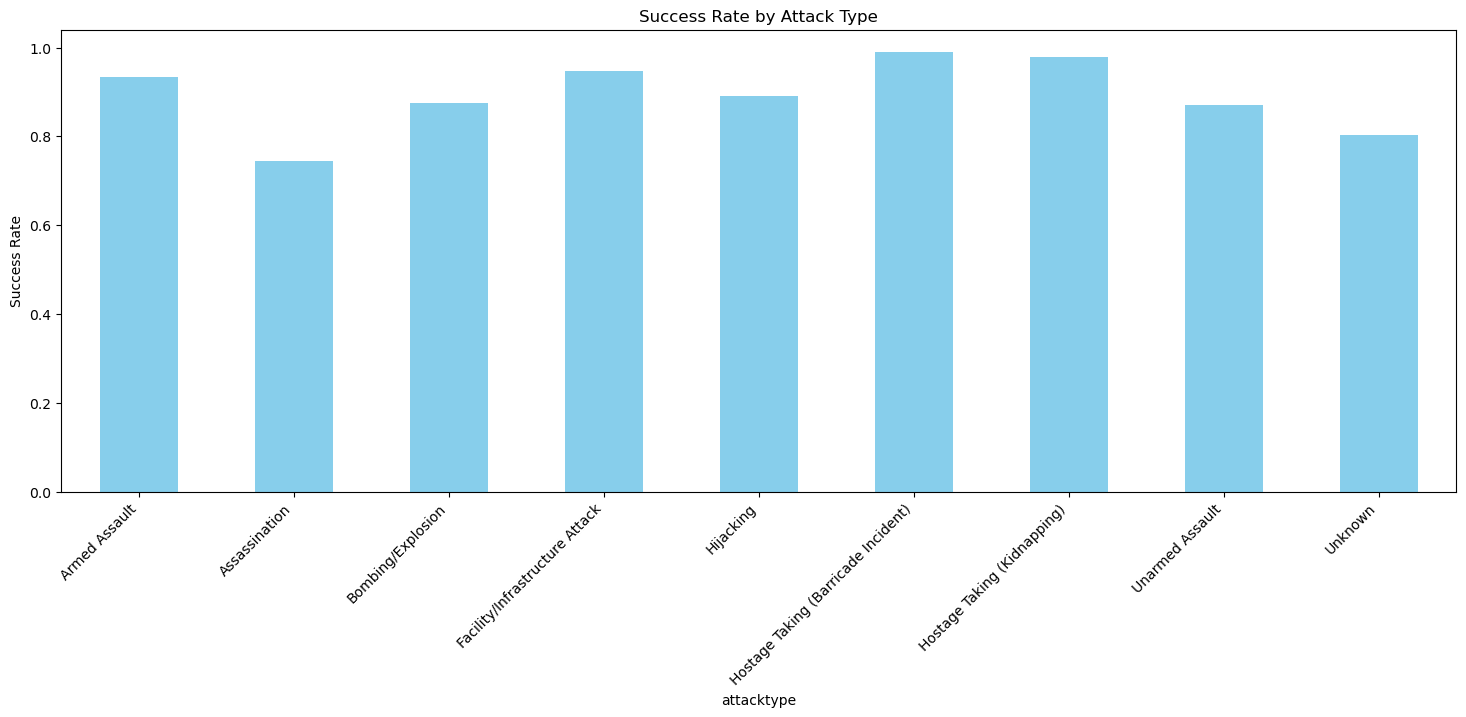

In [98]:
plt.figure(figsize=(18, 6))
success_by_attack_type.plot(kind='bar', color='skyblue')
plt.title('Success Rate by Attack Type')
plt.ylabel('Success Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

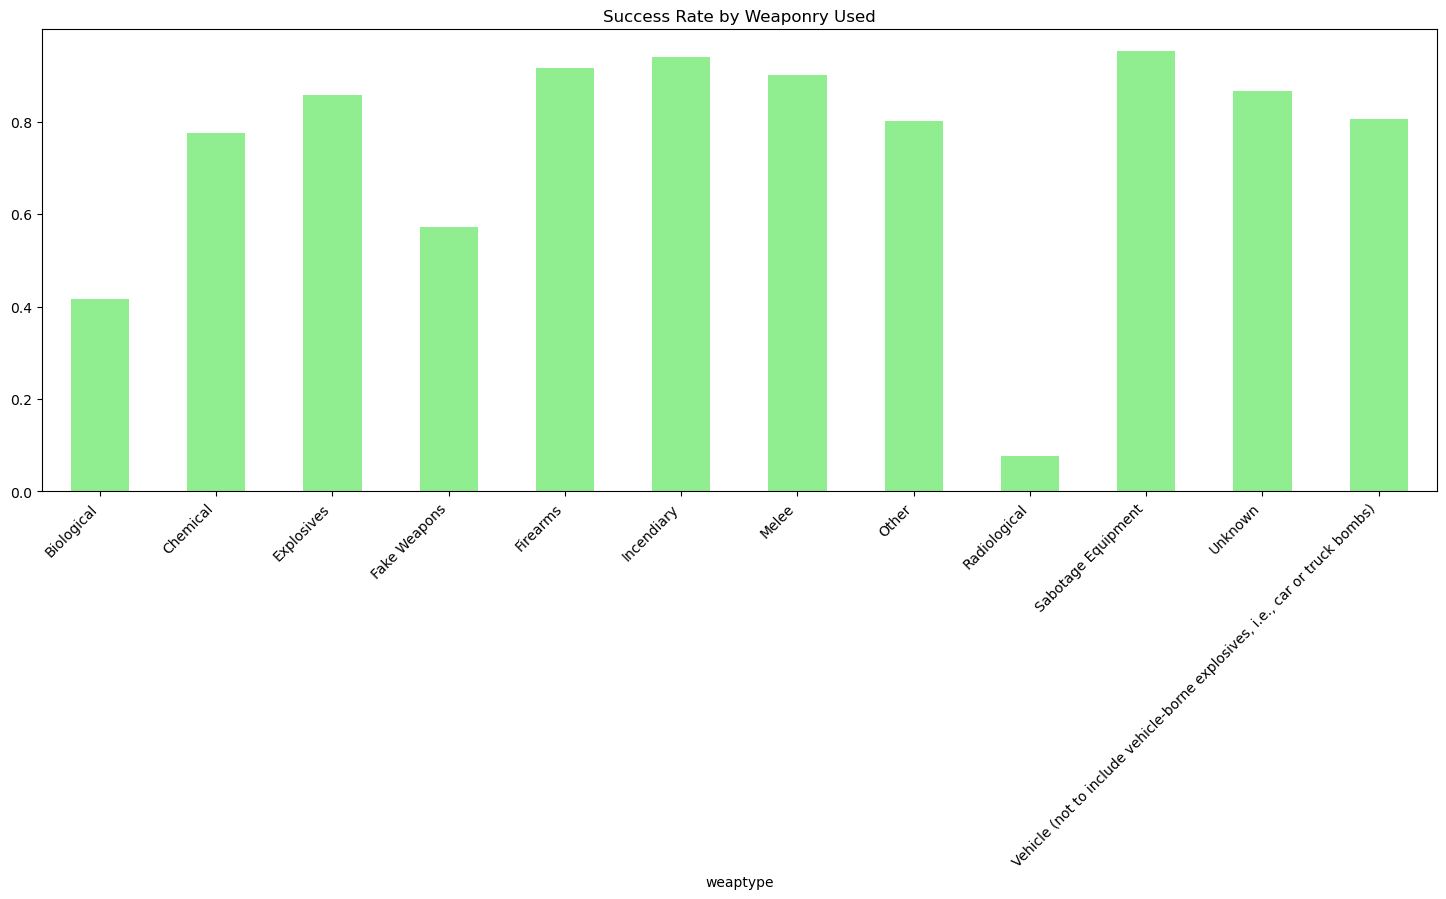

In [97]:
plt.figure(figsize=(18, 6))
success_by_weaponry = df.groupby('weaptype')['success'].mean()
success_by_weaponry.plot(kind='bar', color='lightgreen')
plt.title('Success Rate by Weaponry Used')
plt.xticks(rotation=45, ha='right')
plt.show()

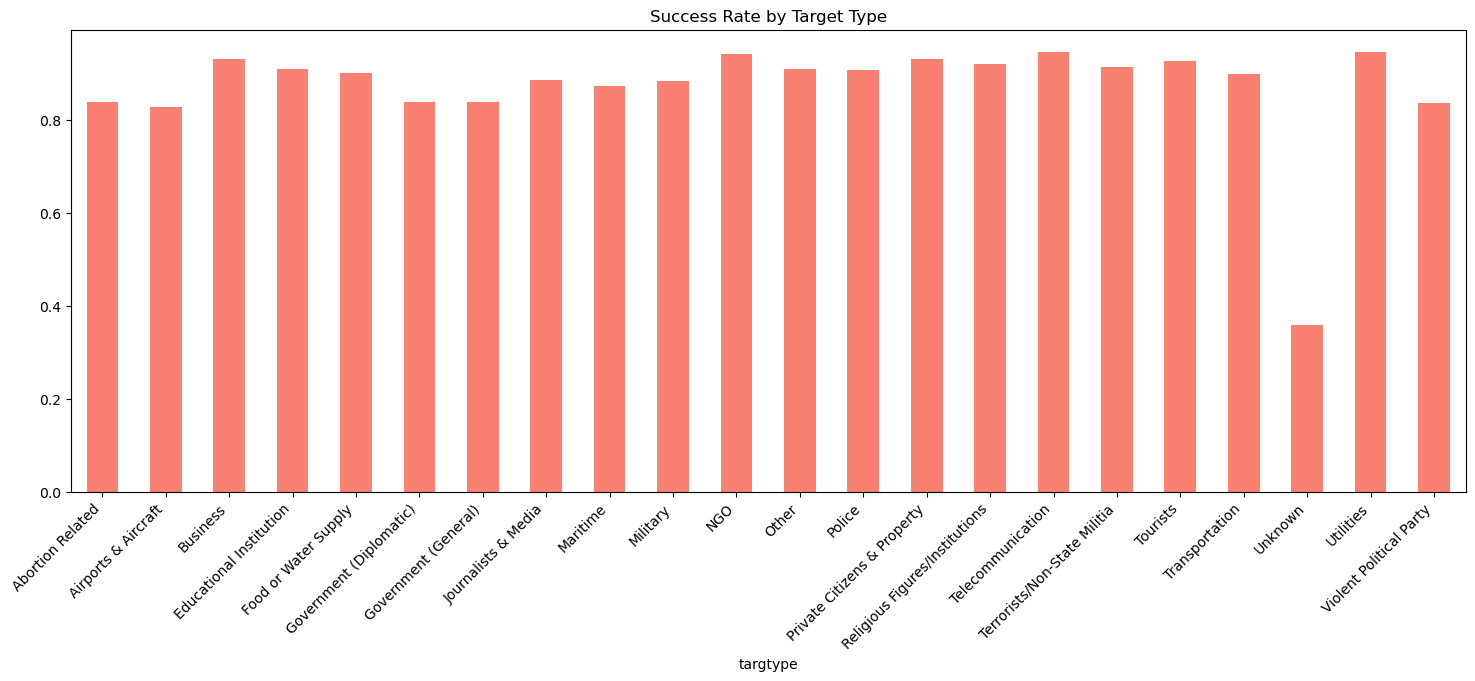

In [96]:
plt.figure(figsize=(18, 6))
success_by_target_type = df.groupby('targtype')['success'].mean()
success_by_target_type.plot(kind='bar', color='salmon')
plt.title('Success Rate by Target Type')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Hostage taking and sabotage equipment are two potent strategies employed in attacks worldwide,leveraging the inherent risks and strategic deployment to achieve success. These tactics have demonstrated their effectiveness in various scenarios, showcasing their impact and versatility. The calculated use of such tools plays a crucial role in the success of these attacks, highlighting the importance of planning and execution. Hostage taking and sabotage are not only effective in causing harm but also in instilling fear and chaos, amplifying their power as tools of aggression. Their ability to disrupt and create turmoil makes them formidable weapons for individuals or groups aiming to achieve their objectives through forceful means.
### 3. Geospatial Analysis: What are the geographical hotspots for terrorist activities? Examine the concentration of attacks by latitude and longitude, and identify if certain cities or provinces have higher incidences

In [161]:
print(df[['latitude', 'longitude']].isnull().sum())

test=df.dropna(subset=['latitude', 'longitude'], inplace=True)

latitude     0
longitude    0
dtype: int64


#### Visualize Geographic Distribution

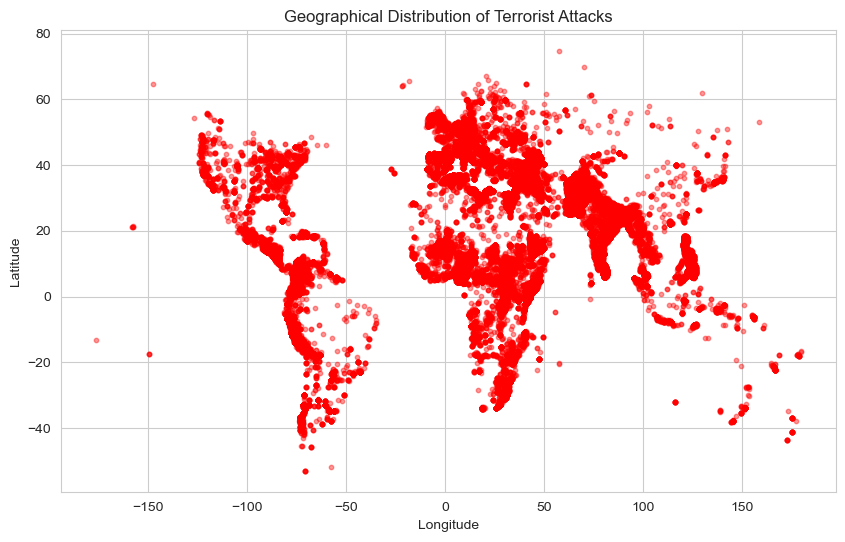

In [162]:
import matplotlib.pyplot as plt

# Plotting all attacks based on latitude and longitude
plt.figure(figsize=(10, 6))
plt.scatter(df['longitude'], df['latitude'], alpha=0.4, color='red', s=10)
plt.title('Geographical Distribution of Terrorist Attacks')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()


### Aggregate Data by City or Province

In [163]:
attacks_by_location = df['city'].value_counts() 

In [105]:
import folium

map = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=2, tiles='cartodbpositron')

for idx, row in df.iterrows():
    folium.CircleMarker(location=[row['latitude'], row['longitude']],
                        radius=2,
                        color='red',
                        fill=True).add_to(map)

map.save('terrorist_activity_map.html')


#### Geographically, the Middle East and North Africa region emerges as a significant hotspot for terrorist activities, characterized by a concentration of attacks in various cities and provinces. The latitude and longitude data reveal a clustering of incidents in this area, indicating a higher incidence of terrorismrelated events. Cities like Baghdad, Kabul, and Damascus have experienced a notable frequency of attacks, underscoring their status as hotspots for terrorist activities. Provinces such as Anbar in Iraq and Kandahar in Afghanistan also stand out for their elevated levels of terrorist incidents. The complex socio-political landscape of the Middle East and North Africa contributes to the prevalence of terrorism in these regions, necessitating comprehensive strategies for addressing and mitigating such threats.
### 4. Attack Types and Impact: Compare the different types of attacks (e.g., bombings, assassinations, kidnappings) and their outcomes in terms of fatalities and injuries. Which attack types are the deadliest?

In [164]:
attack_stats = df.groupby('attacktype').agg({'kills': ['sum', 'mean']}).reset_index()

# Renaming columns for clarity
attack_stats.columns = ['Attack Type', 'Total Fatalities', 'Average Fatalities']

# Display the statistics
print(attack_stats)

                           Attack Type  Total Fatalities  Average Fatalities
0                        Armed Assault          188671.0            3.932448
1                        Assassination           27375.0            1.301093
2                    Bombing/Explosion          200461.0            2.073041
3       Facility/Infrastructure Attack            8491.0            0.698675
4                            Hijacking            4183.0            5.745879
5  Hostage Taking (Barricade Incident)            5663.0            5.024845
6          Hostage Taking (Kidnapping)           54994.0            4.068506
7                      Unarmed Assault             959.0            0.799833
8                              Unknown           55077.0            5.209212


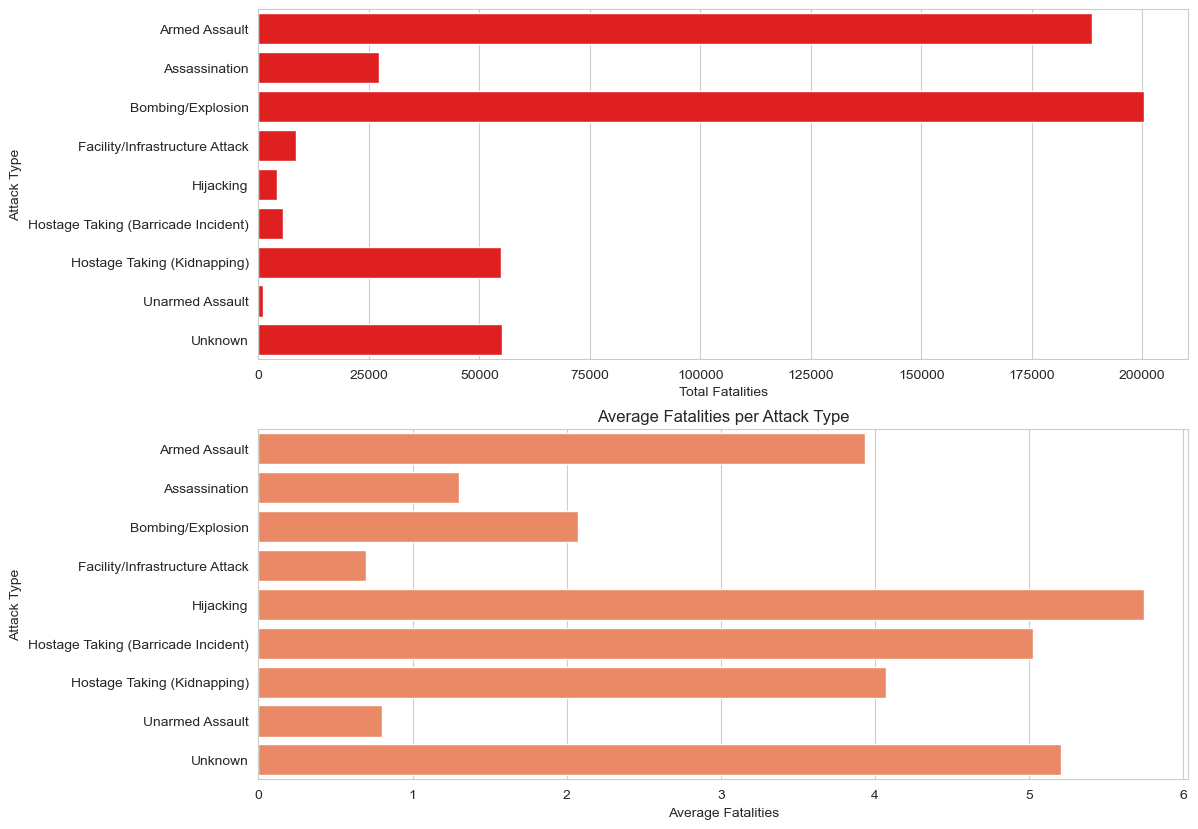

In [165]:

sns.set_style("whitegrid")

f, (ax1,ax2) = plt.subplots(2,1, figsize=(12,10),sharey=True)

g1=sns.barplot(x='Total Fatalities', y='Attack Type', data=attack_stats, color='red',ax=ax1)
plt.title('Total Fatalities by Attack Type')

g2=sns.barplot(x='Average Fatalities', y='Attack Type', data=attack_stats, color='coral',ax=ax2)
plt.title('Average Fatalities per Attack Type')

plt.show()

#### When comparing different types of attacks, armed assault and bombings emerge as the deadliest in terms of fatalities, often resulting in a significant loss of life due to the use of weapons and explosives. These types of attacks tend to cause widespread devastation and casualties. On the other hand, hijacking and hostage situations, while less frequent, have a higher average number of fatalities per incident, as they involve the direct targeting and endangerment of individuals. The nature of these attacks, which often involve prolonged standoffs and negotiations, can lead to tragic outcomes for those involved. Understanding the distinct characteristics and impacts of each attack type is crucial for developing effective counterterrorism strategies and enhancing security measures to prevent such incidents.

### 5. Group Analysis: Which terrorist groups are the most active? Analyze the data to see which groups carry out the most attacks and which groups result in the highest number of fatalities.

In [167]:
groups = df['gang'].value_counts()
groups

gang
Unknown                                        90580
Taliban                                        11954
Islamic State of Iraq and the Levant (ISIL)     7220
Al-Shabaab                                      4403
Shining Path (SL)                               4315
                                               ...  
Union of Young Kurdish Revolutionaries             1
Faqra Tribal Group                                 1
Kurdish demonstrators                              1
Somali Gang                                        1
Martyr Karim Daraam Brigade                        1
Name: count, Length: 3652, dtype: int64

In [168]:
group_stats = df.groupby('gang').agg({'gang': 'count','kills': 'sum'}).rename(columns={'gang': 'Number of Attacks', 'kills': 'Total Fatalities'}).reset_index()
group_stats.sort_values(by='Number of Attacks', ascending=False, inplace=True)
group_stats

,gang,Number of Attacks,Total Fatalities
3515,Unknown,90580,141603.0
3245,Taliban,11954,57931.0
1580,Islamic State of Iraq and the Levant (ISIL),7220,47696.0
182,Al-Shabaab,4403,18450.0
3048,Shining Path (SL),4315,13466.0
...,...,...,...
821,Christian Palestinian group,1,0.0
822,Christian State-Holy Rus,1,0.0
2185,Muslim Commando (Iraqi revolutionary brothers),1,4.0
825,Chukakuha Revolutionary Army,1,0.0


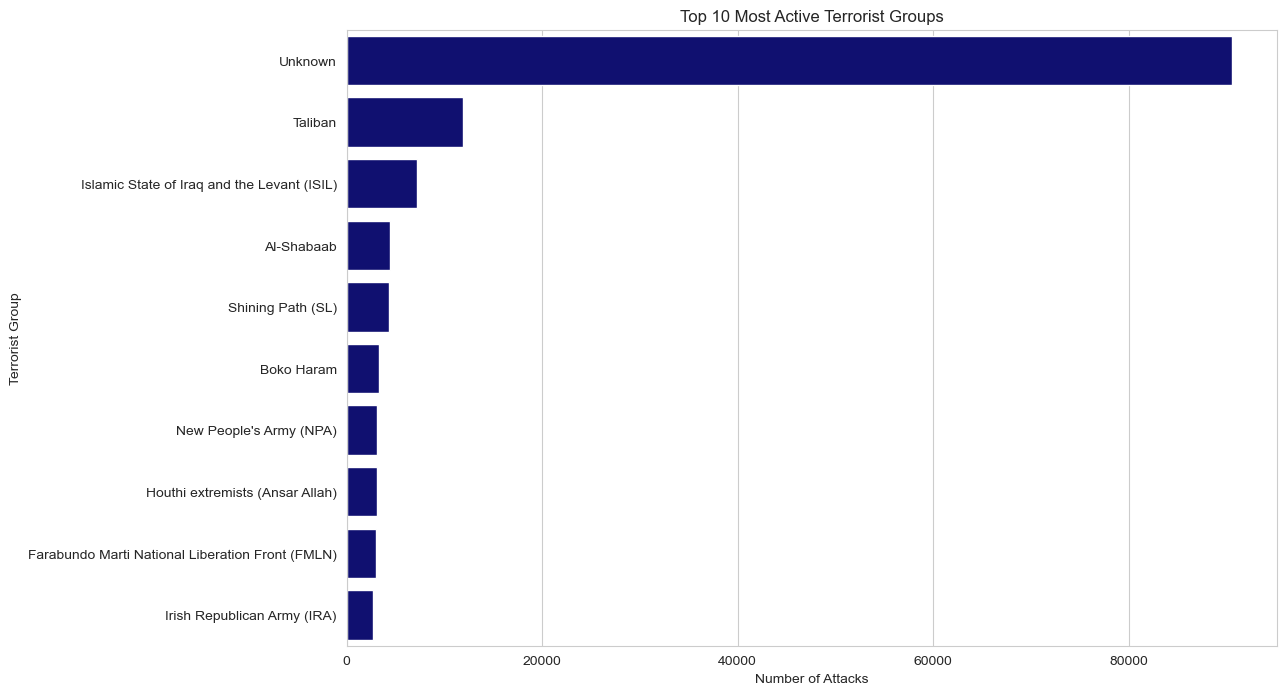

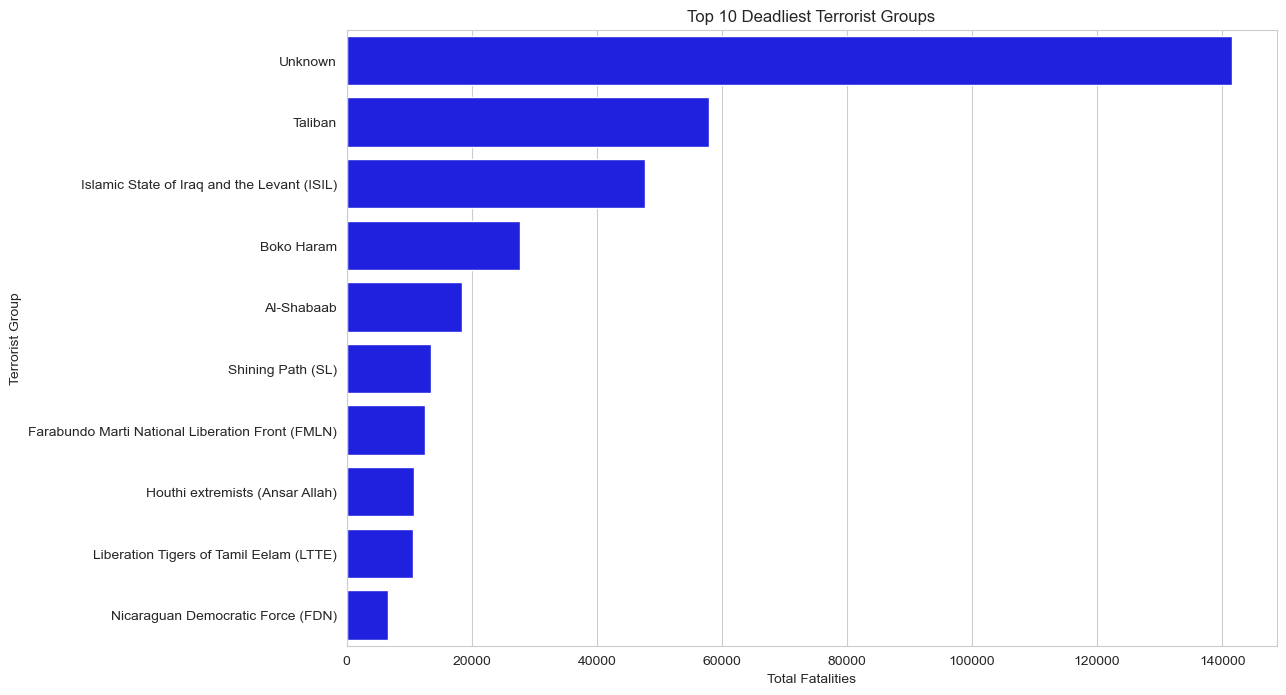

In [169]:
sns.set_style("whitegrid")

# Plotting the number of attacks by groups
plt.figure(figsize=(12, 8))
sns.barplot(x='Number of Attacks', y='gang', data=group_stats.head(10),color='navy')
plt.title('Top 10 Most Active Terrorist Groups')
plt.xlabel('Number of Attacks')
plt.ylabel('Terrorist Group')
plt.show()

# Plotting the number of fatalities by groups
plt.figure(figsize=(12, 8))
sns.barplot(x='Total Fatalities', y='gang', data=group_stats.sort_values(by='Total Fatalities', ascending=False).head(10),color='blue')
plt.title('Top 10 Deadliest Terrorist Groups')
plt.xlabel('Total Fatalities')
plt.ylabel('Terrorist Group')
plt.show()

#### Based on the data analysis, the Taliban emerges as the most active and deadliest terrorist group. The Taliban has been responsible for a significant number of attacks, carrying out operations with high frequency and intensity. Their tactics often result in a high number of fatalities, making them a major threat to security and stability in the regions where they operate. The group's persistent and widespread presence contributes to their status as one of the most active terrorist organizations globally. Their attacks have led to devastating consequences, causing a substantial loss of life and posing a significant challenge to counterterrorism efforts. Understanding the impact and reach of the Taliban is crucial for addressing the ongoing threat they pose and implementing effective measures to combat their activities
### 6. Weapon Types: What are the most common weapon types used in terrorist attacks? Investigate howthe choice of weapon correlates with the number of kills and the success rate of attacks.

In [170]:
weapon_stats = df.groupby('weaptype').agg({'eventid': 'count', 'kills': 'mean',  'success': 'mean'}).rename(columns={'eventid': 'Number of Attacks', 'kills': 'Average Fatalities', 'success': 'Success Rate'}).reset_index()

# Sort the results by the number of attacks
weapon_stats.sort_values(by='Number of Attacks', ascending=False, inplace=True)

In [171]:
weapon_stats

,weaptype,Number of Attacks,Average Fatalities,Success Rate
2,Explosives,102008,2.185878,0.858109
4,Firearms,65653,3.267924,0.914657
10,Unknown,19300,4.199119,0.863005
5,Incendiary,12938,0.863503,0.938940
6,Melee,4219,2.839535,0.899739
1,Chemical,319,2.081505,0.799373
11,Vehicle (not to include vehicle-borne explosiv...,186,17.274194,0.806452
9,Sabotage Equipment,175,0.560000,0.948571
7,Other,136,1.250000,0.801471
0,Biological,34,0.205882,0.411765


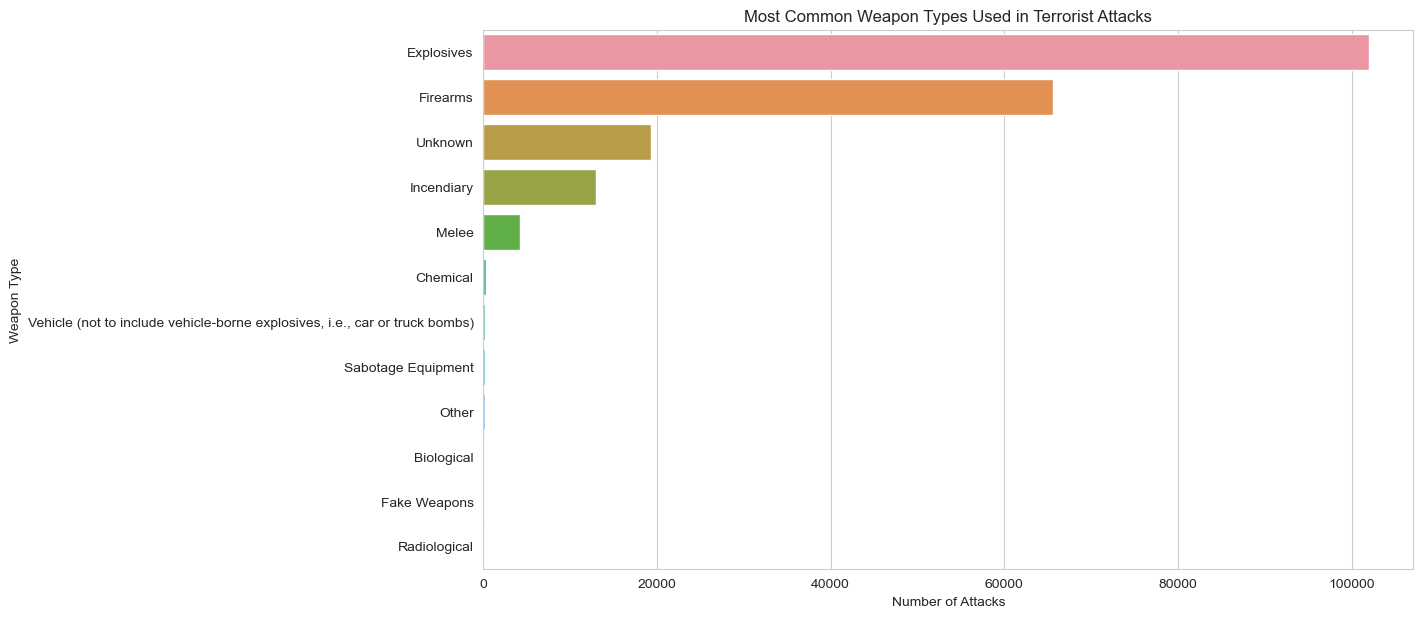

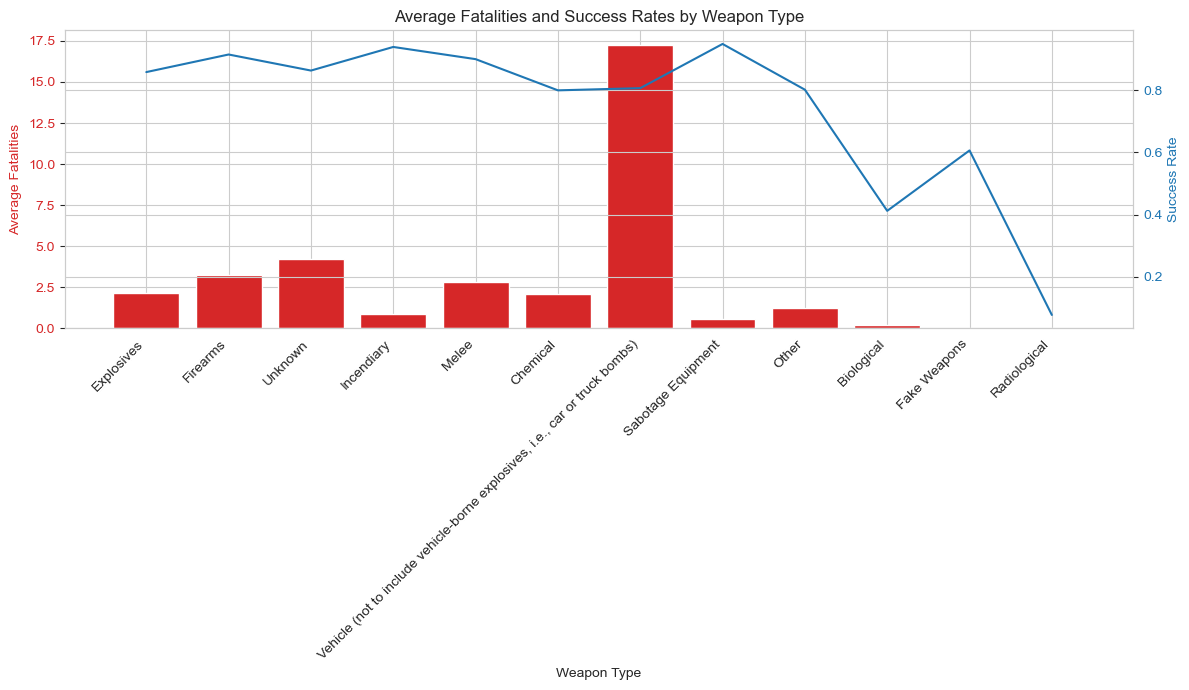

In [172]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Number of Attacks', y='weaptype', data=weapon_stats)
plt.title('Most Common Weapon Types Used in Terrorist Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Weapon Type')
plt.show()

#
fig, ax1 = plt.subplots(figsize=(12, 7))
color = 'tab:red'
ax1.set_xlabel('Weapon Type')
ax1.set_ylabel('Average Fatalities', color=color)
ax1.bar(weapon_stats['weaptype'], weapon_stats['Average Fatalities'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(weapon_stats['weaptype'], rotation=45, ha="right")

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Success Rate', color=color)  
ax2.plot(weapon_stats['weaptype'], weapon_stats['Success Rate'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Average Fatalities and Success Rates by Weapon Type')
fig.tight_layout() 
plt.show()


#### Explosives are indeed the most used weapon type in terrorist attacks, due to their destructive capabilities and relative ease of deployment. Among explosive devices, car or truck bombs stand out for their devastating impact, often resulting in the highest average number of fatalities in attacks where they are employed. The use of vehicles as weapons allows terrorists to cause mass casualties in crowded areas. On the other hand, sabotage equipment, while less common, has a high success rate in achieving the intended objectives of the attackers. This could be attributed to the stealthy nature of sabotage operations and the potential for causing significant damage without direct confrontation. Understanding the correlation between weapon types and their outcomes is crucial for developing effective counterterrorism strategies and enhancing security measures to mitigate the impact of terrorist attacks
### 7. Target Analysis: What types of targets are most frequently attacked? Assess the vulnerability of differenttarget types like government facilities, private citizens, or infrastructure.

In [148]:
# Aggregating data by target type
target_stats = df.groupby('targtype').agg({'targtype': 'count',  'kills': 'mean'}).rename(columns={'targtype': 'Number of Attacks', 'kills': 'Average Fatalities'}).reset_index()

# Sort the results by the number of attacks
target_stats.sort_values(by='Number of Attacks', ascending=False, inplace=True)


In [151]:
target_stats

,targtype,Number of Attacks,Average Fatalities
13,Private Citizens & Property,50984,3.481112
9,Military,33013,4.333929
12,Police,28199,2.501153
6,Government (General),23346,1.559539
2,Business,21777,1.608073
19,Unknown,7090,0.825529
18,Transportation,6919,2.372164
20,Utilities,5854,0.975060
14,Religious Figures/Institutions,5046,3.037852
3,Educational Institution,4706,1.158734


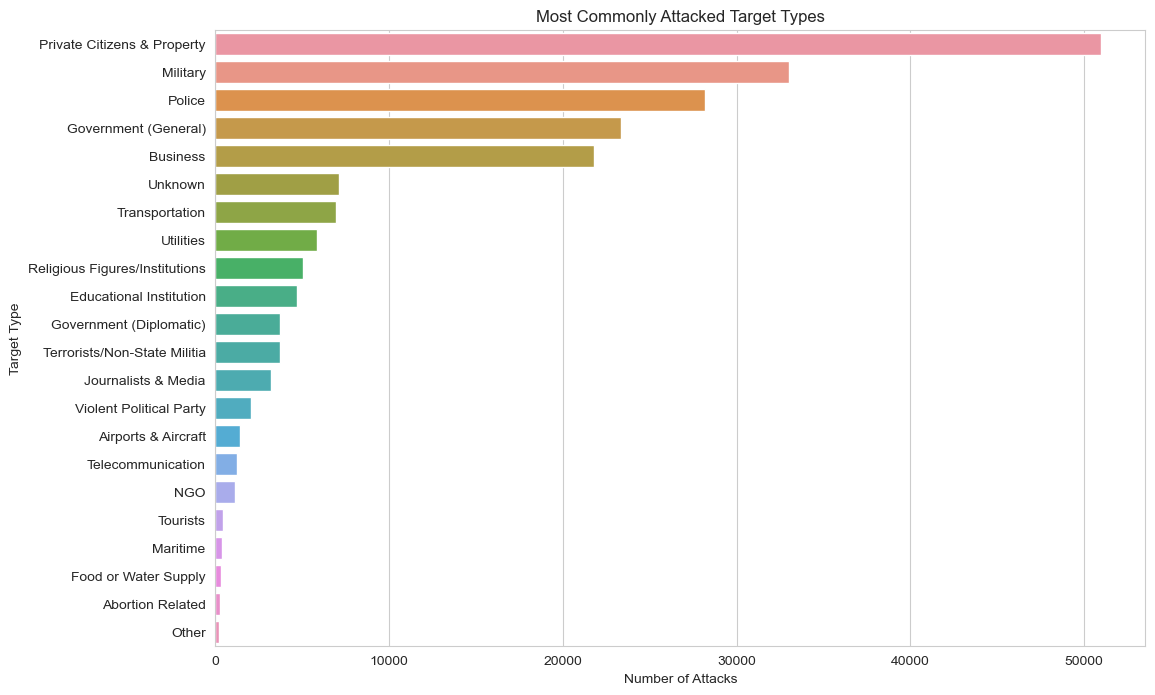

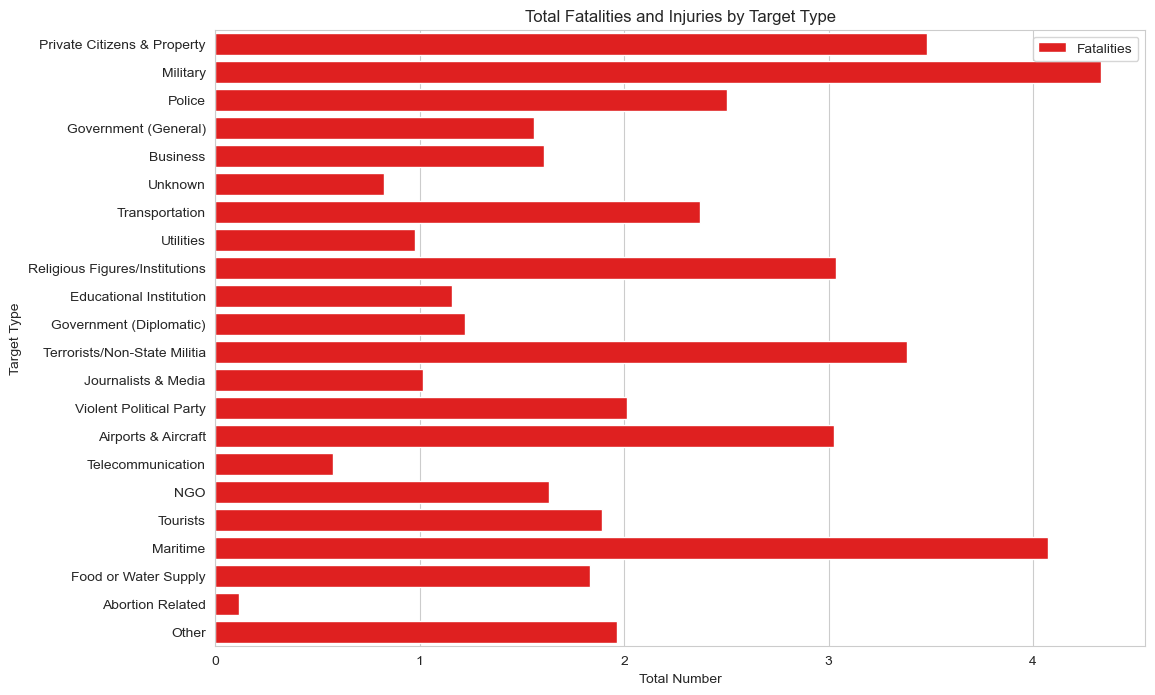

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetic style of the plots
sns.set_style("whitegrid")

# Plotting the number of attacks by target type
plt.figure(figsize=(12, 8))
sns.barplot(x='Number of Attacks', y='targtype', data=target_stats)
plt.title('Most Commonly Attacked Target Types')
plt.xlabel('Number of Attacks')
plt.ylabel('Target Type')
plt.show()

# Plotting total fatalities and injuries by target type
plt.figure(figsize=(12, 8))
sns.barplot(x='Average Fatalities', y='targtype', data=target_stats, color='red', label='Fatalities')
plt.title('Total Fatalities and Injuries by Target Type')
plt.xlabel('Total Number')
plt.ylabel('Target Type')
plt.legend()
plt.show()


#### Based on the data analysis, it is evident that military targets experience the highest number of fatalities in terrorist attacks. This is often due to the strategic importance of military installations and the potential for large-scale casualties in such attacks. On the other hand, private civilians and property are the most frequently targeted by terrorists, reflecting the desire to instill fear and disrupt societal norms. Private citizens are vulnerable targets due to their lack of security measures compared to government facilities or military installations. Attacks on infrastructure, while significant, may not always result in high casualties but can have far-reaching economic and social consequences. Understanding the vulnerability of different target types is essential for prioritizing security measures and allocating resources effectively to protect against terrorist threats.
### 8. Temporal Patterns: Are there specific times of the year, month, or week when terrorist attacks are more frequent? Analyze the timing of attacks to identify any patterns.

In [173]:
# Aggregating data by year, month, and day of the week
attacks_by_year = df['year'].value_counts().sort_index()
attacks_by_month = df['month'].value_counts().sort_index()

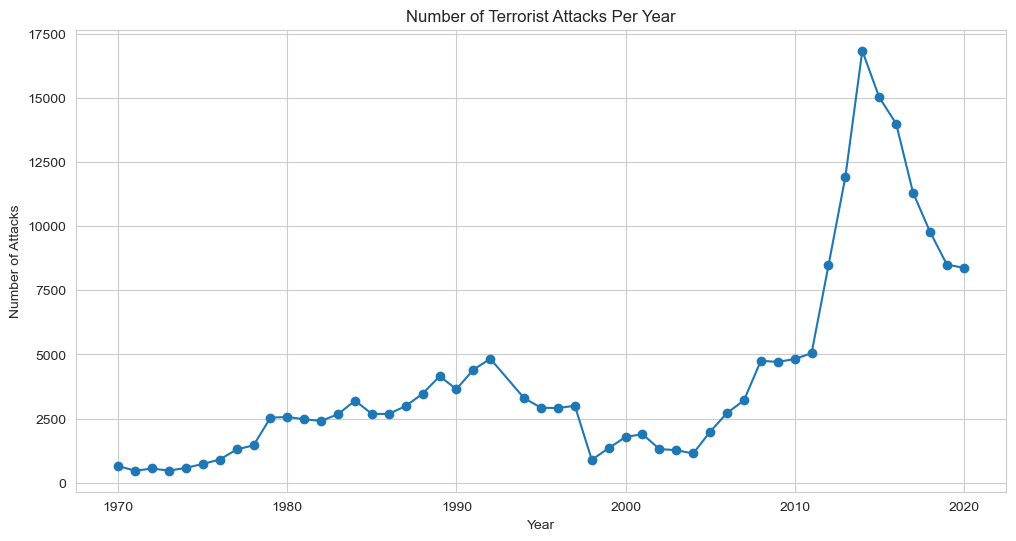

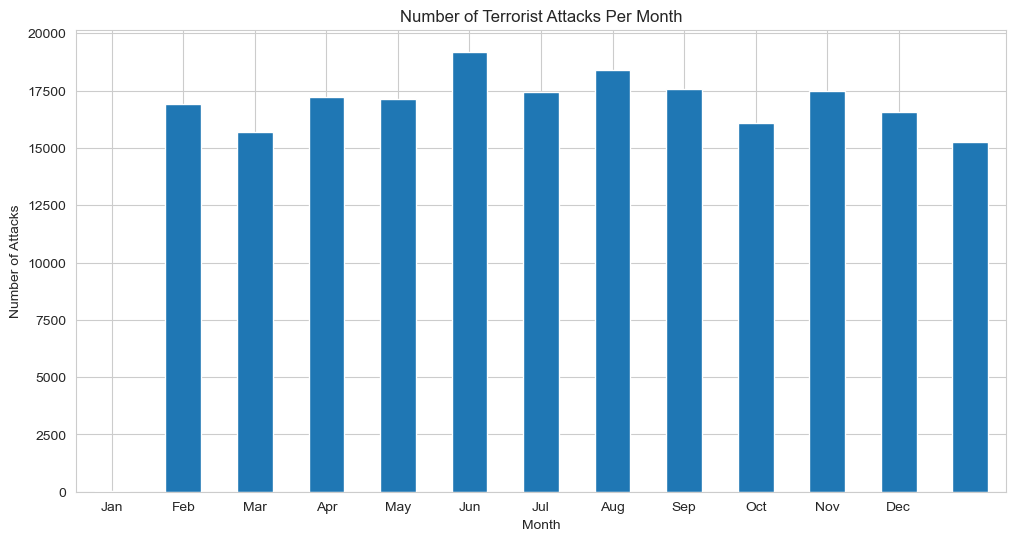

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Plotting attacks by year
plt.figure(figsize=(12, 6))
attacks_by_year.plot(kind='line', marker='o')
plt.title('Number of Terrorist Attacks Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.show()

# Plotting attacks by month
plt.figure(figsize=(12, 6))
attacks_by_month.plot(kind='bar')
plt.title('Number of Terrorist Attacks Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
plt.show()


#### The analysis of temporal patterns in terrorist attacks reveals that 2014 stands out as the year with the highest frequency of attacks. This peak could be attributed to specific geopolitical events or escalations in conflicts within certain regions during that year. Such a spike often indicates significant political or social unrest and may have involved the emergence or resurgence of terrorist groups.
#### Further, the month of June is identified as having the highest number of attacks compared to other months. This finding could suggest a strategic choice, potentially related to weather conditions that are favourable for mobility and operations. June also marks the midpoint of the year, possibly aligning with tactical reassessments and campaign intensifications by terrorist organizations.

### 9. Suicide Attacks: How prevalent are suicide attacks, and how do their outcomes compare to nonsuicide attacks in terms of success rate and casualties?

In [175]:
suicide_attacks = df[df['suicide'] == 1]
non_suicide_attacks = df[df['suicide'] == 0]

In [176]:
# Calculate success rates, average fatalities, and injuries
suicide_stats = {
    'Success Rate': suicide_attacks['success'].mean(),
    'Average Fatalities': suicide_attacks['kills'].mean(),
}

non_suicide_stats = {
    'Success Rate': non_suicide_attacks['success'].mean(),
    'Average Fatalities': non_suicide_attacks['kills'].mean(),
}

print("Suicide Attack Stats:", suicide_stats)
print("Non-Suicide Attack Stats:", non_suicide_stats)


Suicide Attack Stats: {'Success Rate': 0.8362557323981656, 'Average Fatalities': 10.104127326679256}
Non-Suicide Attack Stats: {'Success Rate': 0.8841042510121457, 'Average Fatalities': 2.383410931174089}


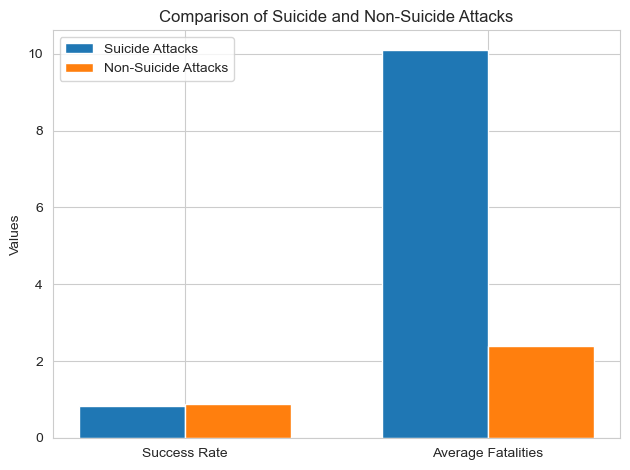

In [179]:
import matplotlib.pyplot as plt

# Labels and values
labels = ['Success Rate', 'Average Fatalities']
suicide_values = [suicide_stats[key] for key in labels]
non_suicide_values = [non_suicide_stats[key] for key in labels]

# The label locations need to be converted from range to list for subtraction/addition
x = list(range(len(labels)))  # Convert range to list
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
# Adjust bar positions by converting positions to list if not already
rects1 = ax.bar([pos - width/2 for pos in x], suicide_values, width, label='Suicide Attacks')
rects2 = ax.bar([pos + width/2 for pos in x], non_suicide_values, width, label='Non-Suicide Attacks')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Values')
ax.set_title('Comparison of Suicide and Non-Suicide Attacks')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.show()


#### Suicide attacks have become increasingly prevalent in recent years, with a significant impact on casualties. The fatalities in suicide attacks are typically higher than in non-suicide attacks due to the intentional targeting of crowded areas. However, the success rate of suicide attacks is comparable to non-suicide attacks, with both types achieving their intended objectives in a similar proportion of cases. Non-suicide attacks may have a slight edge in terms of success rate, possibly due to the element of surprise or the ability to escape after the attack. Overall, the devastating impact of suicide attacks on casualties highlights the need for effective counterterrorism measures to prevent such tragedies.
## Conclusion

#### In conclusion, the analysis of weapon types and target vulnerabilities in terrorist attacks provides valuable insights into the nature of these threats. The prevalence of explosives, especially car or truck bombs, underscores the destructive potential of such weapons and the urgent need for robust security measures to prevent their use by terrorists. Military targets emerge as high-risk locations, with the highest number of fatalities recorded in attacks on these installations, highlighting the strategic importance of safeguarding military facilities. Conversely, private civilians and property are frequently targeted by terrorists, indicating a deliberate intent to in still fear and disrupt societal stability. The vulnerability of these targets underscores the importance of enhancing security measures to protect vulnerable populations and critical infrastructure. Understanding the patterns and trends in terrorist attacks is essential for developing effective counterterrorism strategies that address the diverse threats posed by different weapon types and target types. By prioritizing resources and security measures based on these insights, authorities can better prepare and respond to terrorist threats, ultimately enhancing the safety and security of communities and mitigating the devastating impact of terrorism on society